In [3]:
# Introduction to Convolution Neural Netwwork

In [4]:
# Overview of CNNs and Their role in Image Processing
# Convolutional Neural Network(CNNs):
    # -Specialized type of neural network designed for preprocessing structured grid data, such as images
    # -Particularly effective for image-related tasks like classification, object detection, and Segmentation.

# CNN for image processing:
    # Spatial Hierarchies:
        # -CNNs capture spatial and hierarchical patterns in images 
        # -Convolutional layers extract features like edges, textures, and complex structures
    # Parameter Efficiency:
        # -Unlike fully connected networks, CNNs use fewer parameters due to shared weights, reducing computation and memory requirements.


In [5]:
# CNN Architecture

# key components of CNN:
    # Convolutinal Layers:
        # -perorm convolution operations to extract features
        # -Keras/Filter:
            # -A small matrix(eg:3x3) that slides over the input image to detect patterns 
        # output:
            # -Feature maps highlighting specific patterns in the input

    # Pooling layers:
        # Downsample feature maps to reduce dimensions and computation
        # Types:
            # Max Pooling: Takes the maximum value in a region
            # Average Pooling: Takes the average value in the region

    # Fully connected layers:
        # Combine extracted features to final predictions
        # Act as a "Classifier" in the network

    # Basic CNN workflow:
        # input image -> convolution -> Activation -> Pooling -> Fully Coonected layer -> output

In [6]:
# key advantages of CNNs over fully connected Network for images

# 1.Translation Invariance:
    # -CNNs can detect patterns irrespective of their position in the image

# 2.Reduced parameters:
    # -Sharec weights and local connectivity make CNNs computationally efficient.

# 3.Automatic feature Extraction:
    # -CNNs learn to identify meaningful patterns like edges, shapes, and texture directly from data.

In [7]:
# Exercise objective:
    # Visualize images in a dataset, explore their pixel data, and setup an environment for building CNNs using Tensorflow or PyTorch

In [8]:
# CIPAR10: it divides or kind of classifies all the images into ten different things from 0 to 9
    # 0: airplane
    # 1: automobile
    # 2: bird
    # 3: cat
    # 4: deer
    # 5: dog
    # 6: frog
    # 7: horse
    # 8: ship
    # 9: truck

c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


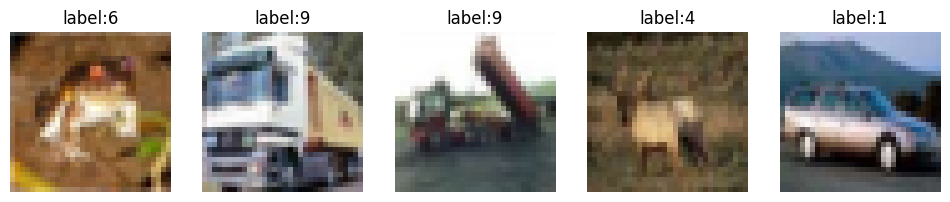

label: 6
image shape:torch.Size([3, 32, 32])
pixel values:
 tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235]

In [9]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import numpy as np 

# load Dataset
transform = transforms.ToTensor() #converts images from dataset into PyTorch tensors
train_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
# root : it specifies the directory where dataset will be stored 
# train = True: load the training dataset
# Transform: applys transformation to tensor to the images and download : download the dataset if it is not already present


# Visualize sample images
fig, axes = plt.subplots(1, 5, figsize=(12,3)) #figure of 1 row , 5 columns for displaying imgaes. figsize: 12inch wide and 3 inch height
for i in range(5):
    image, label = train_dataset[i]
    axes[i].imshow(image.permute(1, 2, 0)) 
    #displaying the images using I am Show. 
        # permute method, which reorders the dimensions from channel height and width to height, width and channels.
        # 1,2,0 means height to first, weidth to second and channel to last 
    axes[i].axis('off') # hide the axis for a cleaner display of image
    axes[i].set_title(f"label:{label}")

plt.show()

# display pixel values for first image
image, label = train_dataset[0]
print(f"label: {label}")
print(f"image shape:{image.shape}")
print(f"pixel values:\n {image}")





In [10]:
# CNN model using tensor flow

import tensorflow as tf

# define a simple CNN model
model = tf.keras.Sequential([
    # first layer is Conv2D which is a convolution layer with 32 filters, keral (3,3), with activation and input_shape
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),

    # MaxPooling2D layer with 2x2 window to reduce the spatial dimensions of the previous input
    tf.keras.layers.MaxPooling2D((2,2)),
     
    #these layer fattens the 2D feature maps into a 1D Vector for fully connected layers 
    tf.keras.layers.Flatten(), 

    # for a fully connected layers with 128 neurons we need to run with activation layer
    tf.keras.layers.Dense(128, activation='relu'),

    # here we need 10 neurons for 10 different classifiers
    tf.keras.layers.Dense(10, activation='softmax')

])

# compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    # compile the model with configurations optimzier with adam optimizer for training.
    # loss with sparse_categorical_crossentropy , specifies the loss function for multi-class classifier 
    # metrics tracks accuracy during training

print("TensorFlow CNN model is ready")



c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TensorFlow CNN model is ready


In [11]:
# CNN model using PyTorch

# this will import the module from pytorch which provides tools for building neural network
import torch.nn as nn

# Define a simple CNN model
class SimpleCNN(nn.Module):
    def __init__(sel):
        super(SimpleCNN, self).__init__()

        # creating the Convolution layer with 3 input channels, 32 filters and 3 by 3 kernel
        self.conv1 = nn.Conv2D(3, 32, kernel_size=3, activation='relu')

        # max pooling 2D with 2x2 window
        self.pool = nn.MaxPool2d(2, 2)

        # fully connected layer or transforming it from 32*15*15 into 128
        self.fc1 = nn.Linear(32 * 15 * 15, 128)
        
        # converting input size to output size where transforming 128 neurins and 10 classes
        self.fc2 = nn.Linear(128, 10)

    # creating a forward pass becauese we need to pass the data through the network 
    def forward(self, x):
        x = F.relu(self.conv1(x))
        # it applies the activation function to the output of the convolution layer

        # here we are using max pooling to reduce the size of the feature map
        x = self.pool(x)

        # here we are using view to flatten the feature map
        x = x.view(-1, 32 * 15 * 15)

        # here we passing the data through the fully connected layer
        x = F.relu(self.fc1(x))

        # here we are passing the data through the fully connected layer
        x = self.fc2(x)

print("PyTorch CNN model is ready")


PyTorch CNN model is ready


In [12]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# load dataset